Week 4:
Post on brightspace
- What the heck is going with the timestamps??? (cleaning needed?)
- What is unmarked data versus hand at rest
- How/were are the channels placed, which muscle 

- Lets do some code and stats on that --> bar charts / histograms
- Lets find missing data? Zeros or NaN values
- For some ML models: one hot encoding needed
- For some ML models: normalization
- 50% feature (making features)

Week 5: 50% feature (analyze features / filter), Linear regression, SVM, Random Forest, 
Week 6: CNN, TS2Vec 
Week 7: compare and stuff
Week 8: Troubleshouting

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("Project_Data_EE4C12_S&S_EMG.csv")

In [ ]:
print(df.keys())

print("Class:")
print(df["class"].value_counts().sort_index())

print("\nLabel:")
print(df["label"].value_counts().sort_index())


Index(['time', 'channel1', 'channel2', 'channel3', 'channel4', 'channel5',
       'channel6', 'channel7', 'channel8', 'class', 'label'],
      dtype='object')
Class:
class
0    2725157
1     250055
2     243193
3     249494
4     251570
5     251733
6     253009
7      13696
Name: count, dtype: int64

Label:
time
0         1
1        58
2        12
3         7
4        32
         ..
97139     1
97140     1
97141     1
97142     1
97143     1
Name: count, Length: 84830, dtype: int64
Max time: 97143
Count: 1
0           21
1           60
2           61
3           65
4           66
         ...  
23300    47442
23301    47443
23302    47444
23303    47445
23304    47446
Name: time, Length: 23305, dtype: int64


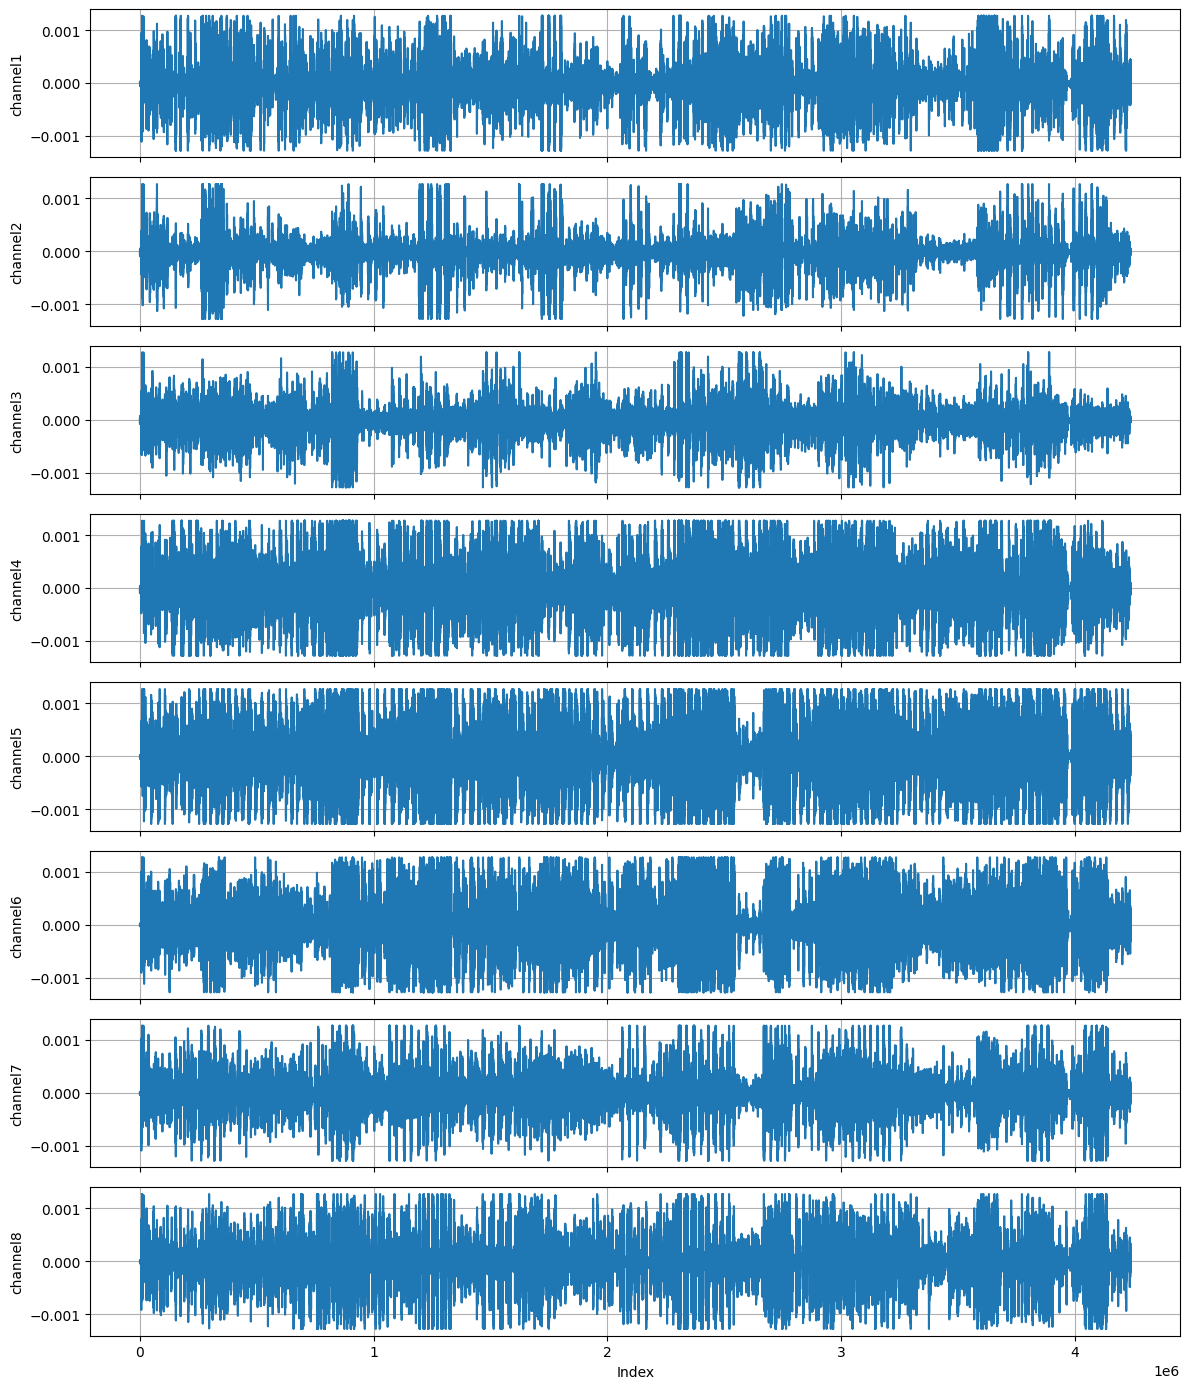

In [8]:
channels = [f"channel{i}" for i in range(1, 9)]

fig, axes = plt.subplots(8, 1, figsize=(12, 14), sharex=True)

for i, channel in enumerate(channels):
    axes[i].plot(df[channel])
    axes[i].set_ylabel(channel)
    axes[i].grid(True)

axes[-1].set_xlabel("Index")
plt.tight_layout()
plt.show()

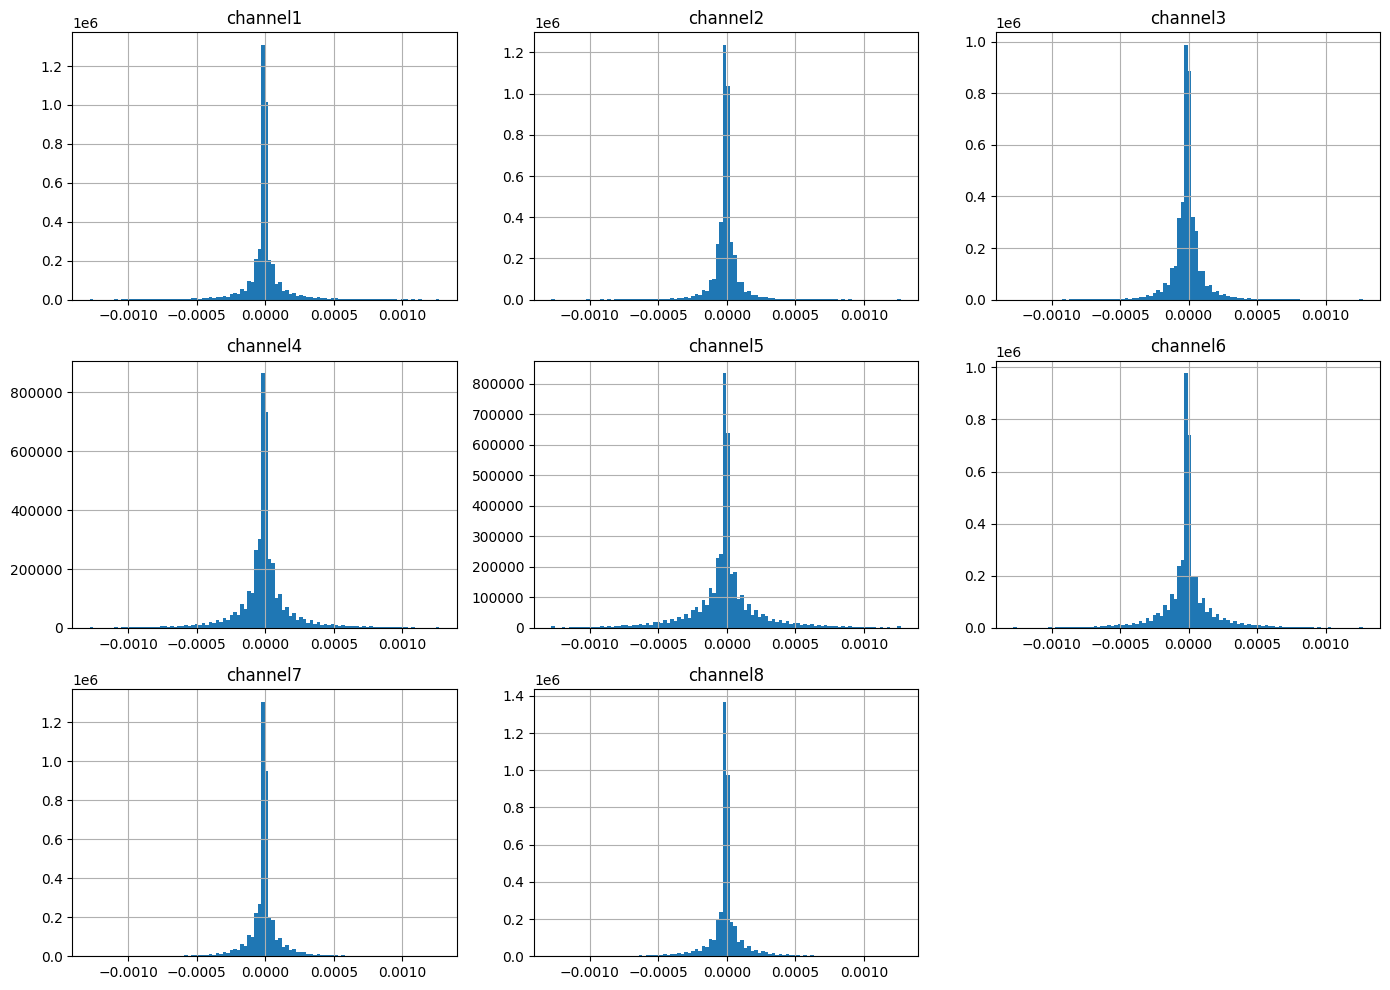

In [11]:
df[channels].describe()

df[channels].hist(
    bins=100,
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

In [13]:
channels = [f"channel{i}" for i in range(1, 9)]

X = df[channels]

# Split eerst
X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

# Fit scaler alleen op training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)